In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!rsync -a --info=progress2 "/content/drive/MyDrive/Datasets/masked_oversampled_noAug_YMY_balance.zip" "/content"

    235,537,888 100%  107.36MB/s    0:00:02 (xfr#1, to-chk=0/1)


In [4]:
import zipfile
with zipfile.ZipFile("masked_oversampled_noAug_YMY_balance.zip", 'r') as zip_ref:
    zip_ref.extractall("./dataset/")

In [2]:
#load the modules
import keras
from keras import models, layers
from keras.activations import relu, softmax
from keras.applications import VGG19
from keras.models import Sequential, load_model, Model
from keras.optimizers import Adam, SGD
from keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Activation, Dropout, Dense, Flatten, GlobalAveragePooling2D
import matplotlib.pyplot as plt
from tensorflow.keras.losses import CategoricalFocalCrossentropy
import sys
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
sys.modules['Image'] = Image

seed = 3434343
keras.utils.set_random_seed(seed)

In [5]:
import cv2
#these are pre-processing steps from Ferreira, I'm just making them compatible with preprocessing_function
#adapted from Joshi, P. (2015). OpenCV with Python by example. Packt Publishing Ltd.
def blurpic(img, size):
    kernel_motion_blur = np.zeros((size, size))
    kernel_motion_blur[int((size-1)/2), :] = np.ones(size)
    kernel_motion_blur = kernel_motion_blur / size
    img = cv2.filter2D(img, -1, kernel_motion_blur)
    return img

#function for gaussian noise transformation
def gnoise(img, mean, sd):
    img = img+ np.random.normal(mean,sd, img.shape)
    img = np.clip(img, 0, 255)
    return img

#function for gaussian blur transformation
def gblur(img, size):
    img=cv2.GaussianBlur(img,(size,size),0)
    return img

def combined_preprocessing(img):
    num = np.random.rand()
    if num < 0.30:
        img = blurpic(img, 15)
        return keras.applications.vgg19.preprocess_input(img)
    elif num <= 0.60:
        img = gnoise(img,15,25)
        return keras.applications.vgg19.preprocess_input(img)
    elif num <= 0.90:
        img = gblur(img, 7)
        return keras.applications.vgg19.preprocess_input(img)
    else:
        img = blurpic(img, 15)
        img = gnoise(img,15,25)
        img = gblur(img, 7)
        return keras.applications.vgg19.preprocess_input(img)

In [6]:
# Keras' data generator can be used to pass the images through the convolutional neural network and apply
#rotation and zoom transformations to the images. Check https://keras.io/preprocessing/image/ for more transformations
train_data = ImageDataGenerator(
        preprocessing_function=combined_preprocessing,
        rotation_range=40,
        horizontal_flip=True,
        vertical_flip=True,
        zoom_range=0.2)

train_generator = train_data.flow_from_directory(
        directory=r"./dataset/train",
        target_size=(224, 224),
        batch_size=8,
        shuffle=True)

Found 8000 images belonging to 16 classes.


In [7]:
#defining the validation data generator
val_data = ImageDataGenerator(preprocessing_function=keras.applications.vgg19.preprocess_input)

val_generator = val_data.flow_from_directory(
        directory=r"./dataset/val",
        target_size=(224, 224),
        batch_size=8,
        shuffle=False)

Found 1051 images belonging to 16 classes.


In [8]:
vgg19 = VGG19(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = vgg19.layers[-1].output
#add dropout and the fully connected layer
dropout_amt = 0.48
x = Dropout(dropout_amt)(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
#add a dense layer with a value equal to the number of classes
predictors = Dense(val_generator.num_classes, activation='softmax')(x)
# Create the model
vgg19model = Model(inputs=vgg19.input, outputs=predictors)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [9]:

# define where to save the model after each epoch
filepath = f"/content/drive/MyDrive/CNN_benchmark/FINAL_kaakaa_drop{dropout_amt}_{seed}/saved_model.h5"
# add a critera to save only if there was an improvement in the model comparing
# to the previous epoch (in this caset the model is saved if there was a decrease in the loss value)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='min')
# stop training if there is no improvement in model for 10 consecutives epochs.
early_stopping_monitor = EarlyStopping(patience=4)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=3, min_lr=1e-6)

callbacks_list = [checkpoint, reduce_lr, early_stopping_monitor]

In [ ]:
# Compile the model
vgg19model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=1e-5),#define the optimizer and the learning rate
              metrics=['acc'])

batch_size=8
epochs=200
model_history=vgg19model.fit(
        train_generator,
        #steps_per_epoch=train_generator.n//batch_size,#unneeded in new keras
        epochs=epochs,
        validation_data=val_generator,
        #validation_steps= val_generator.n//batch_size,#unneeded in new keras
        callbacks=callbacks_list)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - acc: 0.0750 - loss: 3.5179
Epoch 1: val_loss improved from inf to 3.60651, saving model to /content/drive/MyDrive/CNN_benchmark/FINAL_kaakaa_drop0.48_3434343/saved_model.h5


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 267s 243ms/step - acc: 0.0750 - loss: 3.5173 - val_acc: 0.0209 - val_loss: 3.6065 - learning_rate: 1.0000e-05
Epoch 2/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - acc: 0.2395 - loss: 2.3469
Epoch 2: val_loss improved from 3.60651 to 1.07129, saving model to /content/drive/MyDrive/CNN_benchmark/FINAL_kaakaa_drop0.48_3434343/saved_model.h5


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 233s 233ms/step - acc: 0.2396 - loss: 2.3466 - val_acc: 0.6613 - val_loss: 1.0713 - learning_rate: 1.0000e-05
Epoch 3/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - acc: 0.6620 - loss: 1.0555
Epoch 3: val_loss improved from 1.07129 to 1.01717, saving model to /content/drive/MyDrive/CNN_benchmark/FINAL_kaakaa_drop0.48_3434343/saved_model.h5


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 233s 233ms/step - acc: 0.6621 - loss: 1.0553 - val_acc: 0.7640 - val_loss: 1.0172 - learning_rate: 1.0000e-05
Epoch 4/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - acc: 0.8727 - loss: 0.4064
Epoch 4: val_loss improved from 1.01717 to 0.93472, saving model to /content/drive/MyDrive/CNN_benchmark/FINAL_kaakaa_drop0.48_3434343/saved_model.h5


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 238s 238ms/step - acc: 0.8727 - loss: 0.4063 - val_acc: 0.7821 - val_loss: 0.9347 - learning_rate: 1.0000e-05
Epoch 5/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - acc: 0.9370 - loss: 0.2047
Epoch 5: val_loss improved from 0.93472 to 0.90369, saving model to /content/drive/MyDrive/CNN_benchmark/FINAL_kaakaa_drop0.48_3434343/saved_model.h5


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 233s 233ms/step - acc: 0.9370 - loss: 0.2046 - val_acc: 0.7716 - val_loss: 0.9037 - learning_rate: 1.0000e-05
Epoch 6/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - acc: 0.9517 - loss: 0.1539
Epoch 6: val_loss improved from 0.90369 to 0.49125, saving model to /content/drive/MyDrive/CNN_benchmark/FINAL_kaakaa_drop0.48_3434343/saved_model.h5


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 234s 233ms/step - acc: 0.9517 - loss: 0.1539 - val_acc: 0.9020 - val_loss: 0.4913 - learning_rate: 1.0000e-05
Epoch 7/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - acc: 0.9593 - loss: 0.1252
Epoch 7: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 252s 223ms/step - acc: 0.9593 - loss: 0.1252 - val_acc: 0.8820 - val_loss: 0.4927 - learning_rate: 1.0000e-05
Epoch 8/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - acc: 0.9719 - loss: 0.0825
Epoch 8: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 227s 226ms/step - acc: 0.9719 - loss: 0.0825 - val_acc: 0.7897 - val_loss: 0.9718 - learning_rate: 1.0000e-05
Epoch 9/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - acc: 0.9733 - loss: 0.0832
Epoch 9: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 223s 223ms/step - acc: 0.9733 - loss: 0.0832 - val_acc: 0.8126 - val_loss: 0.8249 - learning_rate: 1.0000e-05
Epoch 10/200
1000/1000 ━━━━━━━━━━━━━━

In [ ]:
model=load_model(filepath)

# Compile the model
model.compile(loss='categorical_crossentropy',
             optimizer=SGD(learning_rate=5e-6),
             metrics=['acc'])

#train the model
model_history_2=model.fit(
        train_generator,
        #steps_per_epoch=train_generator.n//batch_size, #keras can now infer this from train_generator length
        epochs=200,
        validation_data=val_generator,
        #validation_steps= val_generator.n//batch_size, #keras can infer this now
        callbacks=callbacks_list)

Epoch 1/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - acc: 0.9656 - loss: 0.1090
Epoch 1: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 216s 212ms/step - acc: 0.9656 - loss: 0.1090 - val_acc: 0.8716 - val_loss: 0.5775 - learning_rate: 5.0000e-06
Epoch 2/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - acc: 0.9721 - loss: 0.0863
Epoch 2: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 211s 211ms/step - acc: 0.9721 - loss: 0.0863 - val_acc: 0.8601 - val_loss: 0.6070 - learning_rate: 5.0000e-06
Epoch 3/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - acc: 0.9821 - loss: 0.0647
Epoch 3: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 210s 210ms/step - acc: 0.9821 - loss: 0.0647 - val_acc: 0.8592 - val_loss: 0.6090 - learning_rate: 5.0000e-06
Epoch 4/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - acc: 0.9797 - loss: 0.0630
Epoch 4: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 210s 210ms/ste

In [10]:
#load the model
model=load_model(filepath)

#check the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,78

 Total params: 26,451,282 (100.90 MB)

 Trainable params: 26,451,280 (100.90 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:

# Compile the model
model.compile(loss='categorical_crossentropy',
             optimizer=SGD(learning_rate=1e-6),
             metrics=['acc'])

#train the model
model_history_3=model.fit(
        train_generator,
        #steps_per_epoch=train_generator.n//batch_size, #keras can now infer this from train_generator length
        epochs=200,
        validation_data=val_generator,
        #validation_steps= val_generator.n//batch_size, #keras can infer this now
        callbacks=callbacks_list)

Epoch 1/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - acc: 0.9682 - loss: 0.1083
Epoch 1: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 216s 211ms/step - acc: 0.9682 - loss: 0.1083 - val_acc: 0.8934 - val_loss: 0.5300 - learning_rate: 1.0000e-06
Epoch 2/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - acc: 0.9745 - loss: 0.0885
Epoch 2: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 215s 214ms/step - acc: 0.9745 - loss: 0.0885 - val_acc: 0.8839 - val_loss: 0.5421 - learning_rate: 1.0000e-06
Epoch 3/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - acc: 0.9766 - loss: 0.0781
Epoch 3: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 212s 212ms/step - acc: 0.9766 - loss: 0.0781 - val_acc: 0.8763 - val_loss: 0.5644 - learning_rate: 1.0000e-06
Epoch 4/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - acc: 0.9700 - loss: 0.0987
Epoch 4: val_loss did not improve from 0.49125
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 215s 215ms/ste

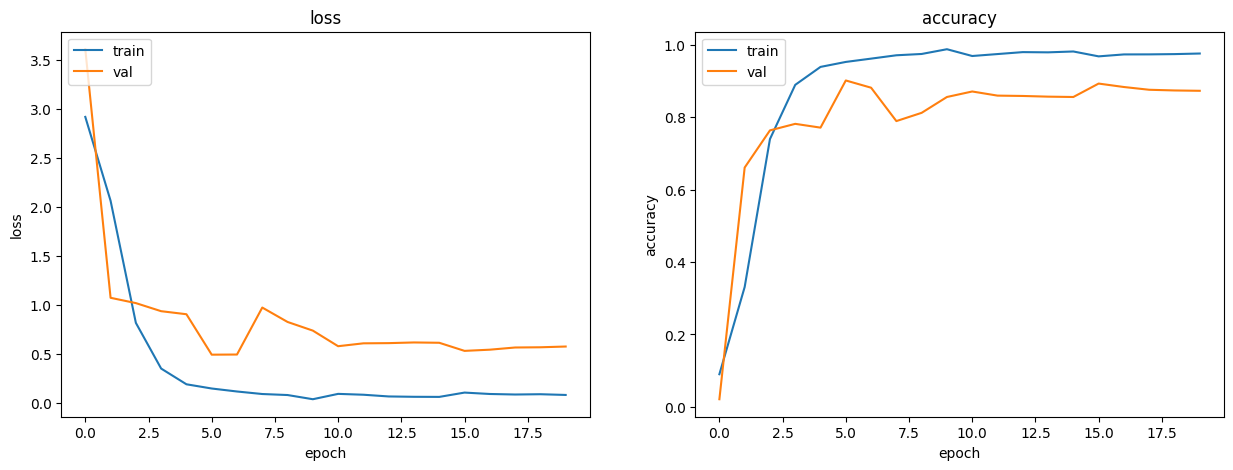

In [ ]:

#size of the plots
fig=plt.figure(figsize=(15,5))
columns = 2
rows = 1

#plot loss
#the accuracy and loss are stored in the "model_history"
fig.add_subplot(rows, columns, 1)
plt.plot(model_history.history['loss']+ model_history_2.history['loss']+ model_history_3.history['loss']) #merge the loss from the two training steps
plt.plot(model_history.history['val_loss']+ model_history_2.history['val_loss']+ model_history_3.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

#plot accuracy
fig.add_subplot(rows, columns, 2)
plt.plot(model_history.history['acc']+ model_history_2.history['acc']+ model_history_3.history['acc'])
plt.plot(model_history.history['val_acc']+ model_history_2.history['val_acc']+ model_history_3.history['val_acc'])
plt.title('accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
!ls dataset/test

000_-Y	002_K-WP  004_L-XX  006_LM-G  008_MR-L	010_P-XX  012_W-BB  014_Y-GL
001_B-	003_L-MB  005_L-YM  007_MO-R  009_O-LW	011_PR-K  013_WX-P  015_YM-Y


In [ ]:
model=load_model(filepath)

In [ ]:
val_sony_datagen1 = ImageDataGenerator(preprocessing_function=keras.applications.vgg19.preprocess_input)
val_sony_datagen = val_sony_datagen1.flow_from_directory(
        directory=r"./dataset/test", #This folder should contain pictures of each bird in a different subfolder (similar to the training data set)
        target_size=(224, 224),
        batch_size=1019,#number of images in the testing dataset
        shuffle=False)

#load the pictures in the testing folder. The x_batch contains the pictures and the y_batch contains the
#identities of the individuals
x_batch, y_batch=next(val_sony_datagen)

#create lists to store the right and the wrong classifications
right_classification=[]
wrong_classification=[]
#loop through all the testing pictures and predict the identity of the individuals
for i in range(0,len(x_batch)):
    image=np.expand_dims(x_batch[i], axis=0)
    result=model.predict(image)
    #if the predicted identity matches the real identity (from the y_batch) store the
    #index of this pcitures in the right classification list. If different store it
    #in the wrong classification list
    if np.where(y_batch[i] == np.amax(y_batch[i]))[0][0]==np.where(result == np.amax(result))[1][0]:
        right_classification.append(i)
    else:
        wrong_classification.append(i)
#print the results
print(len(right_classification)/(len(wrong_classification)+len(right_classification)))

Found 1012 images belonging to 16 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

val_sony_datagen1 = ImageDataGenerator(preprocessing_function=keras.applications.vgg19.preprocess_input)
val_sony_datagen = val_sony_datagen1.flow_from_directory(
        directory=r"./dataset/test", #This folder should contain pictures of each bird in a different subfolder (similar to the training data set)
        target_size=(224, 224),
        batch_size=1019,#number of images in the testing dataset
        shuffle=False)

#load the pictures in the testing folder. The x_batch contains the pictures and the y_batch contains the
#identities of the individuals
x_batch, y_batch=next(val_sony_datagen)

# Predict on the full test set at once instead of looping
preds = model.predict(x_batch)
y_true = np.argmax(y_batch, axis=1)
y_pred = np.argmax(preds, axis=1)

# ---- 1. Overall accuracy ----
overall_acc = np.mean(y_true == y_pred)
print(f"Overall accuracy: {overall_acc:.4f}")

# ---- 2. Per-class accuracy ----
cm = confusion_matrix(y_true, y_pred)
class_acc = cm.diagonal() / cm.sum(axis=1)

class_labels = list(val_sony_datagen.class_indices.keys())

for label, acc in zip(class_labels, class_acc):
    print(f"{label}: {acc:.4f}")

# ---- 3. Detailed report ----
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

Found 1012 images belonging to 16 classes.
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 517ms/step
Overall accuracy: 0.9061
-Y: 0.9922
B-: 0.0000
K-WP: 1.0000
L-MB: 0.1333
L-XX: 1.0000
L-YM: 0.9474
LM-G: 0.9867
MO-R: 0.7273
MR-L: 1.0000
O-LW: 1.0000
P-XX: 0.8000
PR-K: 1.0000
W-BB: 0.0000
WX-P: 0.9453
Y-GL: 0.5455
YM-Y: 0.1429

Classification Report:
              precision    recall  f1-score   support

          -Y       0.97      0.99      0.98       386
          B-       0.00      0.00      0.00        12
        K-WP       0.50      1.00      0.67         6
        L-MB       0.50      0.13      0.21        15
        L-XX       1.00      1.00      1.00        42
        L-YM       0.86      0.95      0.90        19
        LM-G       0.99      0.99      0.99        75
        MO-R       0.97      0.73      0.83        77
        MR-L       1.00      1.00      1.00         5
        O-LW       0.66      1.00      0.79        27
        P-XX       1.00      0.80      0.89         5
        PR-K 

In [ ]:
!rsync -a --info=progress2 "drive/MyDrive/Datasets/masked-Dataset_C.zip" "./"
import zipfile
with zipfile.ZipFile("masked-Dataset_C.zip", 'r') as zip_ref:
    zip_ref.extractall("./dataset-C/")

    101,083,341 100%   91.35MB/s    0:00:01 (xfr#1, to-chk=0/1)


In [ ]:
test_sony_datagen = ImageDataGenerator(preprocessing_function=combined_preprocessing)
test_sony_datagen = test_sony_datagen.flow_from_directory(
        directory=r"./dataset-C/", #This folder should contain pictures of each bird in a different subfolder (similar to the training data set)
        target_size=(224, 224),
        batch_size=5218,#number of images in the testing dataset
        shuffle=True)

Found 5218 images belonging to 17 classes.


In [ ]:
B_indices = train_generator.class_indices
C_indices = test_sony_datagen.class_indices

all_overlaps = []

print(B_indices)
print(C_indices)

for (key, value) in B_indices.items():
  if key in C_indices:
    overlap = { "key": key, "indices": { "B":value, "C":C_indices[key] } }
    all_overlaps.append(overlap)

print(all_overlaps)


{'-Y': 0, 'B-': 1, 'K-WP': 2, 'L-MB': 3, 'L-XX': 4, 'L-YM': 5, 'LM-G': 6, 'MO-R': 7, 'MR-L': 8, 'O-LW': 9, 'P-XX': 10, 'PR-K': 11, 'W-BB': 12, 'WX-P': 13, 'Y-GL': 14, 'YM-Y': 15}
{'-B': 0, '-Y': 1, 'B-': 2, 'K-PW': 3, 'KR-L': 4, 'L-MB': 5, 'LM-G': 6, 'MO-R': 7, 'O-LW': 8, 'OL-Y': 9, 'RM-X': 10, 'W-GL': 11, 'WX-P': 12, 'X-XX': 13, 'XX-O': 14, 'Y-GL': 15, 'YM-Y': 16}
[{'key': '-Y', 'indices': {'B': 0, 'C': 1}}, {'key': 'B-', 'indices': {'B': 1, 'C': 2}}, {'key': 'L-MB', 'indices': {'B': 3, 'C': 5}}, {'key': 'LM-G', 'indices': {'B': 6, 'C': 6}}, {'key': 'MO-R', 'indices': {'B': 7, 'C': 7}}, {'key': 'O-LW', 'indices': {'B': 9, 'C': 8}}, {'key': 'WX-P', 'indices': {'B': 13, 'C': 12}}, {'key': 'Y-GL', 'indices': {'B': 14, 'C': 15}}, {'key': 'YM-Y', 'indices': {'B': 15, 'C': 16}}]


In [ ]:
invert_B = {v: k for k, v in B_indices.items()}
invert_C = {v: k for k, v in C_indices.items()}

In [ ]:
merged = B_indices | C_indices
print("merged:", merged)
confusion = {
        'tp': 0,
        'tn': 0,
        'fp': 0,
        'fn': 0
    }

all_class_stats = {}
for k,v in merged.items():
  all_class_stats[k] = confusion.copy()

model=load_model(filepath)
#load the pictures in the testing folder. The x_batch contains the pictures and the y_batch contains the
#identities of the individuals
x_batch, y_batch=next(test_sony_datagen)

#create lists to store the right and the wrong classifications
right_classification=[]
wrong_classification=[]
for i in range(0,len(x_batch)):
    image=np.expand_dims(x_batch[i], axis=0)
    result=model.predict(image)

    #the model predicts using the 16 dataset B classes it was trained on
    #let's get the index of the most likely class
    predicted_class = np.where(result == np.amax(result))[1][0]
    #and now the index of the true class
    true_class = np.where(y_batch[i] == np.amax(y_batch[i]))[0][0]
    #match our ints to their respective labels
    B_predicted_label = invert_B[predicted_class]
    C_true_label = invert_C[true_class]

    print(f"image {i}, true label: {C_true_label}, predicted label: {B_predicted_label}")
    if C_true_label in B_indices: #we're only testing the accuracy of birds we've trained on, as the cnn won't know anything else
      if B_predicted_label == C_true_label:
        right_classification.append(i)
      else:
        wrong_classification.append(i)

    #an embarrassing mess. the good news is I will never be hired

    for cls in all_class_stats:
      #true positive
      if cls == B_predicted_label and cls == C_true_label:
        all_class_stats[cls]['tp'] += 1
      elif cls == B_predicted_label and cls != C_true_label:
        all_class_stats[cls]['fp'] += 1
      elif cls != B_predicted_label and cls == C_true_label:
        all_class_stats[cls]['fn'] += 1
      elif cls != B_predicted_label and cls != C_true_label:
        #true neg
        all_class_stats[cls]['tn'] += 1

print(all_class_stats)
print(len(right_classification)/(len(wrong_classification)+len(right_classification)))


merged: {'-Y': 1, 'B-': 2, 'K-WP': 2, 'L-MB': 5, 'L-XX': 4, 'L-YM': 5, 'LM-G': 6, 'MO-R': 7, 'MR-L': 8, 'O-LW': 8, 'P-XX': 10, 'PR-K': 11, 'W-BB': 12, 'WX-P': 12, 'Y-GL': 15, 'YM-Y': 16, '-B': 0, 'K-PW': 3, 'KR-L': 4, 'OL-Y': 9, 'RM-X': 10, 'W-GL': 11, 'X-XX': 13, 'XX-O': 14}


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
image 2719, true label: YM-Y, predicted label: YM-Y
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
image 2720, true label: W-GL, predicted label: MR-L
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
image 2721, true label: B-, predicted label: -Y
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
image 2722, true label: -Y, predicted label: -Y
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
image 2723, true label: X-XX, predicted label: MR-L
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
image 2724, true label: B-, predicted label: L-MB
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
image 2725, true label: B-, predicted label: B-
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
image 2726, true label: YM-Y, predicted label: YM-Y
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
image 2727, true label: B-, predicted label: PR-K
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
image 2728, true label: KR-L, predicted label: MR-L
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
image 2729, true label: B-,

In [ ]:
print(len(right_classification)/(len(wrong_classification)+len(right_classification)))

print(len(right_classification))

print(len(wrong_classification))

0.5189757658893461
1135
1052


In [ ]:
final_stats = {}
print(all_class_stats)
def calculate_stats():
  for cls in all_class_stats:

    true_pos = all_class_stats[cls]['tp']

    false_pos = all_class_stats[cls]['fp']

    false_neg = all_class_stats[cls]['fn']

    true_neg = all_class_stats[cls]['tn']

    #taken from my cgp-cnn fork lol
    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0

    recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0

    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    #it's never going to guess birds it hasn't trained on, so we set those to acc 0
    accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg) if cls in B_indices else 0

    final_stats[cls] = {"precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy}
    print(f"class {cls}: {final_stats[cls]}")
calculate_stats()

{'-Y': {'tp': 576, 'tn': 4088, 'fp': 395, 'fn': 159}, 'B-': {'tp': 239, 'tn': 3118, 'fp': 3, 'fn': 1858}, 'K-WP': {'tp': 0, 'tn': 5038, 'fp': 180, 'fn': 0}, 'L-MB': {'tp': 7, 'tn': 4872, 'fp': 135, 'fn': 204}, 'L-XX': {'tp': 0, 'tn': 5213, 'fp': 5, 'fn': 0}, 'L-YM': {'tp': 0, 'tn': 5204, 'fp': 14, 'fn': 0}, 'LM-G': {'tp': 5, 'tn': 5122, 'fp': 5, 'fn': 86}, 'MO-R': {'tp': 0, 'tn': 3794, 'fp': 1411, 'fn': 13}, 'MR-L': {'tp': 0, 'tn': 4513, 'fp': 705, 'fn': 0}, 'O-LW': {'tp': 14, 'tn': 4955, 'fp': 160, 'fn': 89}, 'P-XX': {'tp': 0, 'tn': 5218, 'fp': 0, 'fn': 0}, 'PR-K': {'tp': 0, 'tn': 4299, 'fp': 919, 'fn': 0}, 'W-BB': {'tp': 0, 'tn': 5218, 'fp': 0, 'fn': 0}, 'WX-P': {'tp': 41, 'tn': 4770, 'fp': 8, 'fn': 399}, 'Y-GL': {'tp': 0, 'tn': 5058, 'fp': 0, 'fn': 160}, 'YM-Y': {'tp': 389, 'tn': 4777, 'fp': 7, 'fn': 45}, '-B': {'tp': 0, 'tn': 5106, 'fp': 0, 'fn': 112}, 'K-PW': {'tp': 0, 'tn': 5190, 'fp': 0, 'fn': 28}, 'KR-L': {'tp': 0, 'tn': 4902, 'fp': 0, 'fn': 316}, 'OL-Y': {'tp': 0, 'tn': 5211, 

In [ ]:
i = 0
total_acc = 0
for cls in final_stats:
  if cls in C_indices and cls in B_indices:
    print(f"{cls}: {final_stats[cls]}")
    total_acc += final_stats[cls]['accuracy']
    i += 1

avg = total_acc / i
print(f"Average accuracy for birds across datasets: {avg}")

-Y: {'precision': 0.5932028836251287, 'recall': 0.7836734693877551, 'f1': 0.675263774912075, 'accuracy': 0.8938290532771177}
B-: {'precision': 0.987603305785124, 'recall': 0.1139723414401526, 'f1': 0.20436083796494228, 'accuracy': 0.6433499425067075}
L-MB: {'precision': 0.04929577464788732, 'recall': 0.03317535545023697, 'f1': 0.039660056657223795, 'accuracy': 0.9350325795323879}
LM-G: {'precision': 0.5, 'recall': 0.054945054945054944, 'f1': 0.099009900990099, 'accuracy': 0.9825603679570717}
MO-R: {'precision': 0.0, 'recall': 0.0, 'f1': 0, 'accuracy': 0.7270985051743963}
O-LW: {'precision': 0.08045977011494253, 'recall': 0.13592233009708737, 'f1': 0.10108303249097472, 'accuracy': 0.9522805672671522}
WX-P: {'precision': 0.8367346938775511, 'recall': 0.09318181818181819, 'f1': 0.16768916155419225, 'accuracy': 0.9220007665772326}
Y-GL: {'precision': 0, 'recall': 0.0, 'f1': 0, 'accuracy': 0.9693369106937524}
YM-Y: {'precision': 0.9823232323232324, 'recall': 0.8963133640552995, 'f1': 0.9373

In [14]:
model.save("best_cnn_model.keras")
!cp best_cnn_model.keras /content/drive/MyDrive/